In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):

        n_features = X.shape[1]

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors = []
        self.history = []

        for epoch in range(self.epochs):

            error_count = 0

            for xi, target in zip(X, y):

                linear_output = (
                    np.dot(xi, self.weights)
                    + self.bias
                )

                prediction = self.activation(
                    linear_output
                )

                update = self.lr * (
                    target - prediction
                )

                self.weights += update * xi
                self.bias += update

                error_count += int(update != 0)

            self.errors.append(error_count)

            self.history.append(
                (
                    self.weights.copy(),
                    self.bias
                )
            )

    def predict(self, X):

        linear_output = (
            np.dot(X, self.weights)
            + self.bias
        )

        return self.activation(
            linear_output
        )


In [8]:

def plot_boundaries(X, y, model, title):

    epochs = len(model.history)

    plt.figure(figsize=(15,3))

    for i, (w, b) in enumerate(model.history):

        plt.subplot(2,5,i+1)

        plt.scatter(
            X[:,0],
            X[:,1],
            c=y,
            cmap='coolwarm',
            s=100
        )

        x_values = np.array([-0.5,1.5])

        if w[1] != 0:

            y_values = -(w[0]*x_values + b)/w[1]

            plt.plot(
                x_values,
                y_values
            )

        plt.title(f"Epoch {i+1}")
        plt.xlim(-0.5,1.5)
        plt.ylim(-0.5,1.5)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [9]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

In [10]:
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

In [11]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

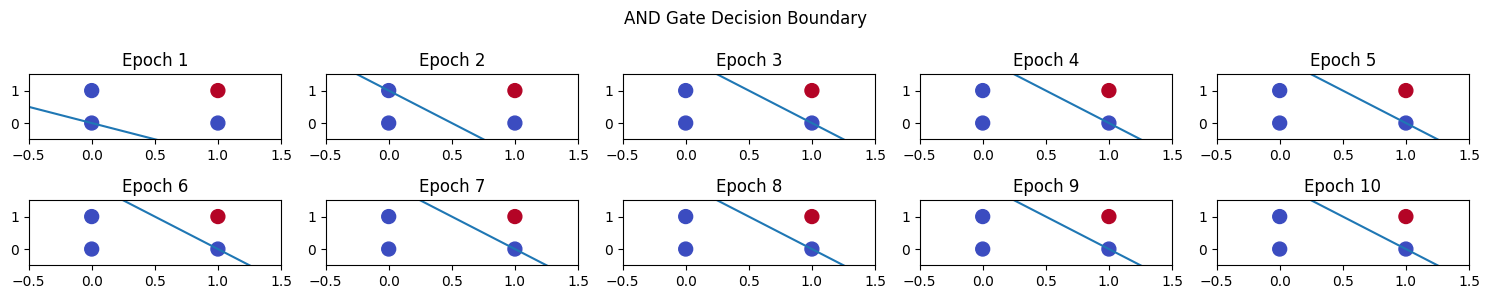

In [12]:
and_model = Perceptron(
    learning_rate=0.1,
    epochs=10
)

and_model.fit(X_and, y_and)

plot_boundaries(
    X_and,
    y_and,
    and_model,
    "AND Gate Decision Boundary"
)

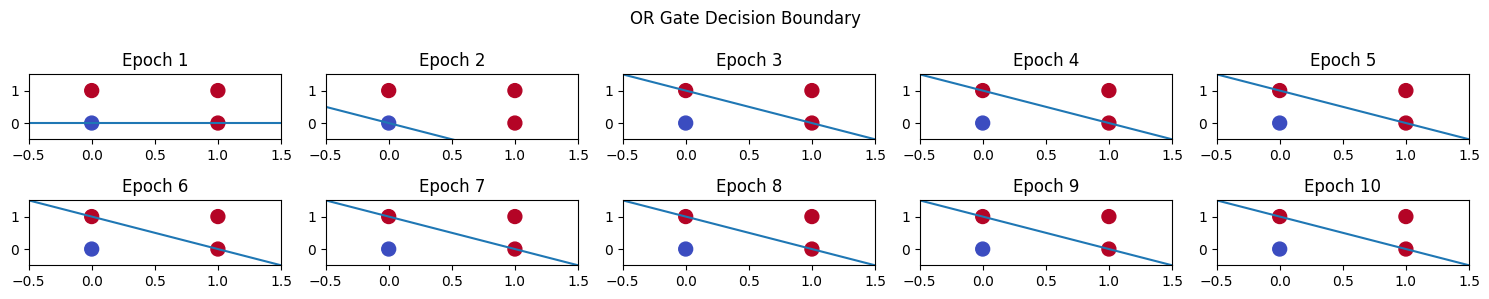

In [13]:
or_model = Perceptron(
    learning_rate=0.1,
    epochs=10
)

or_model.fit(X_or, y_or)

plot_boundaries(
    X_or,
    y_or,
    or_model,
    "OR Gate Decision Boundary"
)

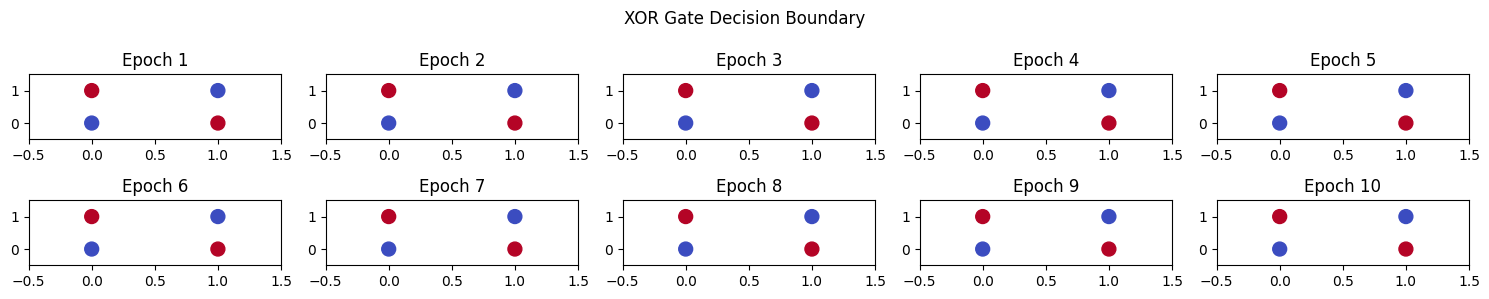

In [14]:
xor_model = Perceptron(
    learning_rate=0.1,
    epochs=10
)

xor_model.fit(X_xor, y_xor)

plot_boundaries(
    X_xor,
    y_xor,
    xor_model,
    "XOR Gate Decision Boundary"
)

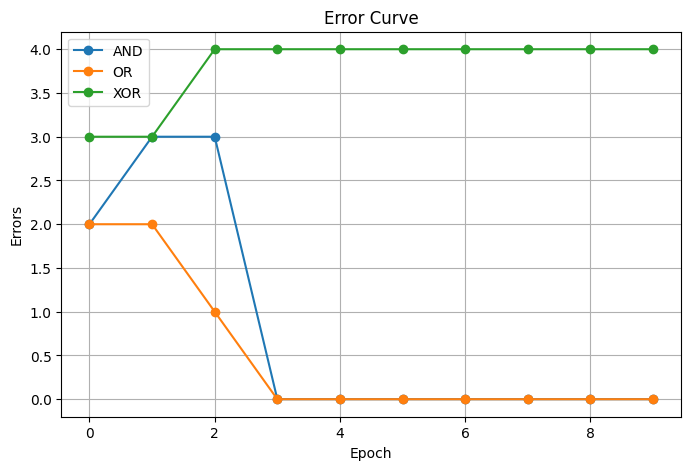

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    and_model.errors,
    marker='o',
    label='AND'
)

plt.plot(
    or_model.errors,
    marker='o',
    label='OR'
)

plt.plot(
    xor_model.errors,
    marker='o',
    label='XOR'
)

plt.xlabel("Epoch")
plt.ylabel("Errors")

plt.title("Error Curve")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
print("AND Predictions:")
print(and_model.predict(X_and))

print("\nOR Predictions:")
print(or_model.predict(X_or))

print("\nXOR Predictions:")
print(xor_model.predict(X_xor))

AND Predictions:
[0 0 0 1]

OR Predictions:
[0 1 1 1]

XOR Predictions:
[1 1 0 0]
